In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize

In [2]:
def opening_files(file_name, lighting = 'light'):
        dir_ = 'moser_dl'
        file_path =  os.path.join(dir_ , file_name)
        data = np.load(file_path , allow_pickle=True).item()
        if lighting=='light':
            section = 1
        elif lighting=='dark':
            section = 0

        # light = 1
        # dark = 0
        st = data["task"][section]["spike_timestamp"]
        cid = data["task"][section]["spike_cluster_id"]

        open_field_light_1 = data['task'][section]

        neurons_id = np.unique(open_field_light_1 ["spike_cluster_id"])
        module_id = data['module_id']

        this_rat = {}
        t = data['task'][section]['tracking']['t']
        t0 = t[0]

        this_rat['t'] = t-t[0]
        this_rat['x'] = data['task'][section]['tracking']['x']
        this_rat['y'] = data['task'][section]['tracking']['y']
        this_rat['z'] = data['task'][section]['tracking']['z']
        this_rat['hd'] = data['task'][section]['tracking']['hd']
        this_rat['grid_mod1'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 1]}
        this_rat['grid_mod2'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 2]}
        this_rat['grid_mod3'] = {int(i):st[cid == i]-t0  for i in neurons_id[module_id == 3]}
        dt = np.mean( this_rat['t'][1:] - this_rat['t'][:-1])
        speed = np.sqrt( ( this_rat['x'][1:] - this_rat['x'][:-1] )**2 + ( this_rat['y'][1:] - this_rat['y'][:-1] ) **2 )  / dt
        this_rat['speed'] = np.append([0] , speed) #assuming the motion is starting at speed 0

        return this_rat
# rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')

# rat1 = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'light')
# rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'light')
# rat3 = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'light')
# rat4 = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'light')
# rat5 = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'light')

# rat1_dark = opening_files('moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy' , 'dark')
# rat2_dark = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'dark')
# rat3_dark = opening_files('moserlab_waaga_26018_2019-12-14_16-03-44_v1.npy' , 'dark')
# rat4_dark = opening_files('moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy' , 'dark')
# rat5_dark = opening_files('moserlab_waaga_26820_2020-11-05_11-03-13_v1.npy' , 'dark')

In [25]:
rat2 = opening_files('moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy' , 'light')
X  = rat2['x']      # (cm)
Y  = rat2['y']      # (cm)
Z  = rat2['z']      # (cm)

HD = rat2['hd']     # (rad) double check the units and the point of reference 
T  = rat2['t']      # (s)
V = rat2['speed']   # (cm/s)
# V[np.where(V > 100)] =0 
ind_ = np.where((V < 100) & (V > 3))
X = X[ind_]
Y = Y[ind_]
Z = Z[ind_]
HD = HD[ind_]
T= T[ind_]
V = V[ind_]

In [3]:
def rad_to_deg(x):
    return x * 180 / np.pi
def deg_to_rad(x):
    return x * np.pi / 180
def np_standard(x):
    return (x - np.min(x)) / ( np.max(x) -  np.min(x))

# Head Direction

In [ ]:
# TODO: 
# figure out head direction in the data 
# code the one step conditional, normal with v and theta 
# visualize the results
# how good is the estimation? 

In [5]:
np.min(HD), np.max(HD), np.mean(HD)

(np.float64(-3.14157563913332),
 np.float64(3.14158680448517),
 np.float64(0.3589668268142966))

## allocentric headind directon

In [21]:
guess_HD = np.arctan((Y[1:] - Y[:-1]) / (X[1:] - X[:-1]))
guess_HD2 = np.arctan2((Y[1:] - Y[:-1]) , (X[1:] - X[:-1]))

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1120/3713308219.py:1: RuntimeWarning: divide by zero encountered in divide
  guess_HD = np.arctan((Y[1:] - Y[:-1]) / (X[1:] - X[:-1]))
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1120/3713308219.py:1: RuntimeWarning: invalid value encountered in divide
  guess_HD = np.arctan((Y[1:] - Y[:-1]) / (X[1:] - X[:-1]))


In [ ]:
smoothed_HD  = gaussian_filter(guess_HD  , sigma=deg_to_rad(4) )
smoothed_HD2 = gaussian_filter(guess_HD2 , sigma=deg_to_rad(4) )

In [108]:
a = 5000
b = 6000

In [97]:
smoothed_HD2.shape

(234128,)

(5000.0, 6000.0)

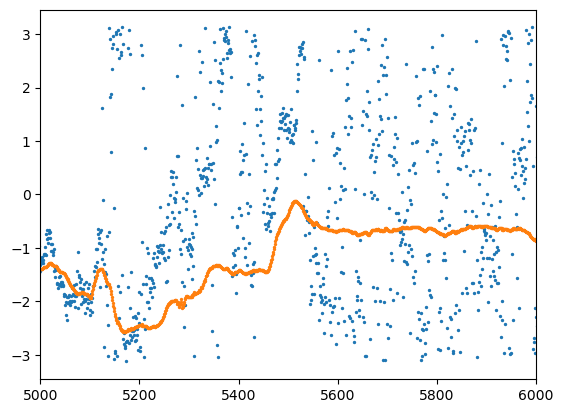

In [109]:
plt.scatter(range(smoothed_HD2.shape[0]) , smoothed_HD2 , s = 2)
plt.scatter(range(HD.shape[0]) , HD           , s = 2)
# plt.plot(V)
# plt.xlim(1000, 9000)
plt.xlim(a, b)
# plt.plot((Y[1:] - Y[:-1]) / (X[1:] - X[:-1]))



Based on the trends I'm seeing in reported HD and calculated allocentric headind directon, they seem to be correlated. 

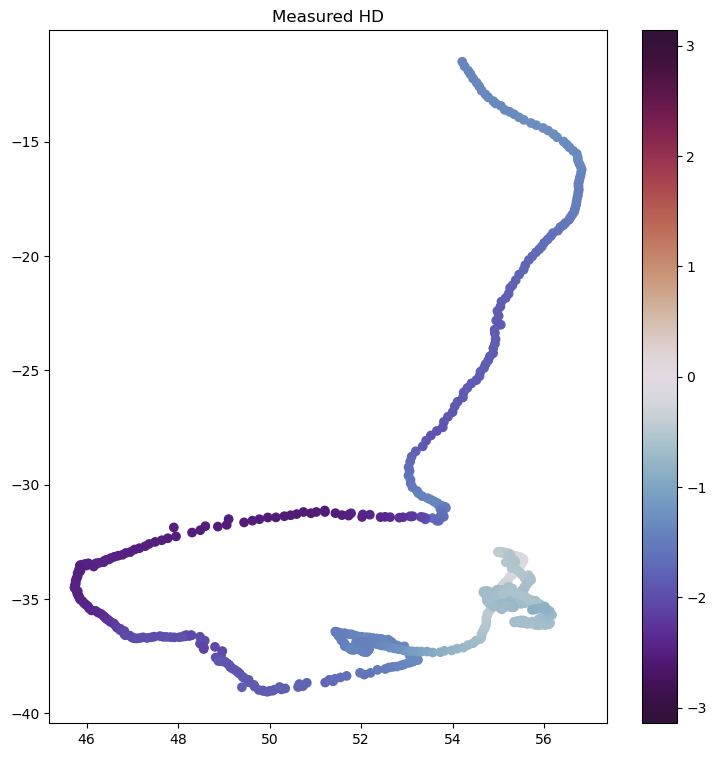

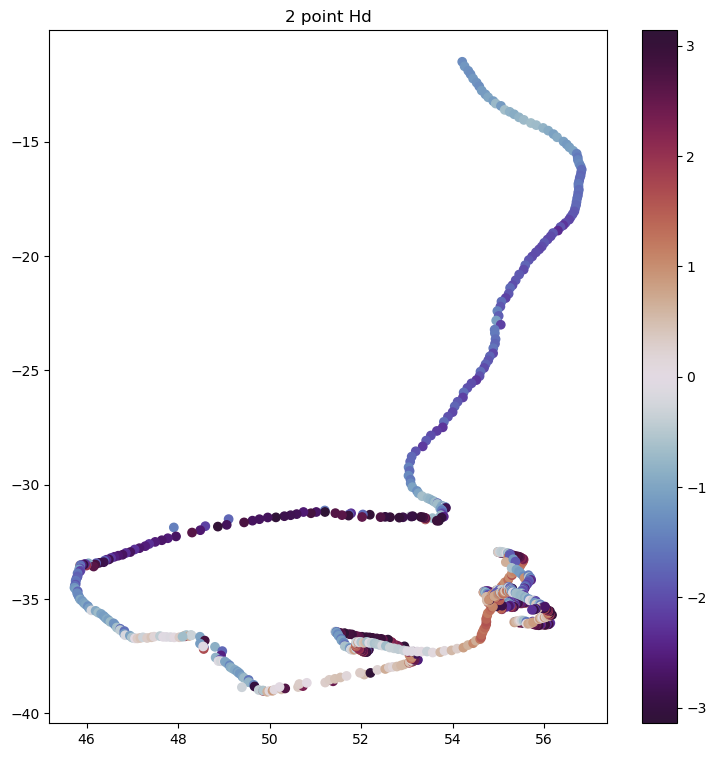

In [110]:
norm = Normalize(vmin=-np.pi, vmax=np.pi)

plt.figure(figsize=(9, 9)) 
# plt.scatter(X[a:b], Y[a:b] , c= smoothed_HD2[a: b])
sc1 = plt.scatter(X[a:b], Y[a:b] , c= HD[a:b] , cmap='twilight_shifted' , norm=norm)
plt.colorbar()
plt.title('Measured HD')
plt.show()

plt.figure(figsize=(9, 9)) 
sc2 = plt.scatter( X[a:b], Y[a:b] , c= smoothed_HD2[a:b] , cmap='twilight_shifted', norm=norm)
plt.colorbar()
plt.title('2 point Hd')
plt.show()



   

## Egocentric head direction

In [5]:
def get_triangle_angel(i):
    A = np.array([float(X[i])   , float(Y[i])])
    B = np.array([float(X[i+1]) , float(Y[i+1])])
    C = np.array([float(X[i+2]) , float(Y[i+2])])
    BA = B - A
    BC = B - C
    cos_theta = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC))
    # print(cos_theta)
    return np.pi - np.arccos(cos_theta)



In [10]:
egoc_HD = []
for i in range(len(X) - 3):
    egoc_HD.append(get_triangle_angel(i))

/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_1120/3200973935.py:7: RuntimeWarning: invalid value encountered in scalar divide
  cos_theta = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC))


(5000.0, 6000.0)

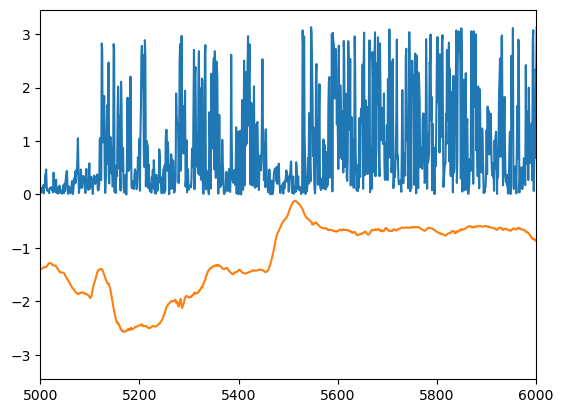

In [19]:
plt.plot(egoc_HD)
plt.plot(HD)

plt.xlim(5000,6000)

Looks like egocentric head direction is not explaining the trends observed in the reported head direction. 
Based on the the information given in the paper that they used a six OptiTrack Flex 13 cameras and Motive software system to record the movement and analyze it, they have potentially measured the yaw around the +z axis to record the head direction. The remaining question at this point is what is the the point of reference for the measurements of the alocentric head direction. 

## head direction point of refernce

(5000.0, 10000.0)

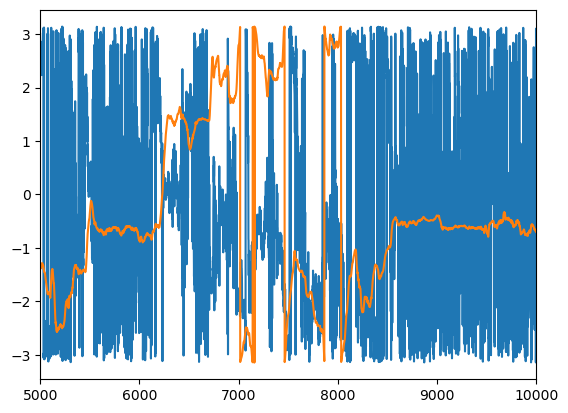

In [127]:
guess_HD2_pov = np.arctan2( (X[1:] - X[:-1]) , (Y[1:] - Y[:-1]))
plt.plot(guess_HD2_pov)
# plt.plot(smoothed_HD2)
plt.plot(HD)

plt.xlim(5000, 10000)



The original standard assumption seemed to be the best one. Note that there are 

# Position estimation 

In [136]:
dt  = 1/120
mu_x = X[:-1] + V[:-1] * dt * np.cos(HD[:-1])
mu_y = Y[:-1] + V[:-1] * dt * np.sin(HD[:-1])

residuals = np.stack([
        X[1:] - mu_x,
        Y[1:] - mu_y
    ], axis=1)

sigma = np.cov(residuals, rowvar=False)


In [137]:
dt  = 1/120
mu_x = X[:-1] + V[:-1] * dt * np.cos(HD[:-1])
mu_y = Y[:-1] + V[:-1] * dt * np.sin(HD[:-1])

mu = np.stack([mu_x, mu_y], axis=1)          # (T-1, 2)
actual = np.stack([X[1:], Y[1:]], axis=1)    # (T-1, 2)

residuals = actual - mu                      # (T-1, 2)

Sigma_inv = np.linalg.inv(sigma)
logdet = np.log(np.linalg.det(sigma))

# Mahalanobis term
quad_form = np.einsum("ni,ij,nj->n", residuals, Sigma_inv, residuals)

nll = 0.5 * np.sum(quad_form + logdet + 2 * np.log(2 * np.pi))
nll_per_step = nll / residuals.shape[0]

In [140]:
np.unique(quad_form)

array([2.14775278e-07, 2.99668091e-07, 4.22173436e-07, ...,
       4.43177742e+02, 5.43395126e+02, 6.83171002e+02])

In [138]:
nll, nll_per_step

(np.float64(-629853.1941119254), np.float64(-2.6902087495383955))

# particle filter approach 

In [26]:
grid_mod1 = rat2['grid_mod1']
grid_mod2 = rat2['grid_mod2']
grid_mod3 = rat2['grid_mod3']
all_activity  = {}
all_activity.update(grid_mod1)
all_activity.update(grid_mod2)
all_activity.update(grid_mod3)


In [37]:
from mec_position_decoder import DecoderConfig, run_decode_comparison, summary_table

cfg = DecoderConfig(
    n_particles=1500,
    n_x_bins=40,
    n_y_bins=40,
    process_noise_cm=0.3,
    rate_smoothing_sigma_bins=1.2,
    random_seed=0,
)

results = run_decode_comparison(
    spikes_by_cell=all_activity,  # {cell_id: spike_times_sec}
    x=X, y=Y, t=T, hd=HD, speed=V,
    cfg=cfg,
    train_fraction=0.7
)

print(summary_table(results))


Decoder comparison:
- spikes only:      RMSE=33.61 cm, median=8.83 cm
- spikes+HD+speed:  RMSE=10.45 cm, median=7.52 cm
- improvement:      RMSE=68.9%, median=14.9%
Modulation (test period):
- median |beta_speed|: 0.250
- median HD strength:  0.294
- median delta LL:     48.489


In [11]:
results.keys() , results['spikes_only']

(dict_keys(['cell_ids', 'counts', 'train_idx', 'test_idx', 'x_edges', 'y_edges', 'occupancy', 'rate_maps_hz', 'spikes_only', 'spikes_plus_motion', 'modulation']),
 DecodeResult(x_hat=array([-12.72414431,  10.82989095, -30.85538791, ..., -11.21045163,
        -11.17026958, -11.12409769]), y_hat=array([-32.56798986,  -3.23524871,  13.9375422 , ..., -25.82654268,
        -25.96004727, -26.05347857]), error_cm=array([57.95887901, 73.02129888, 35.23522578, ...,  8.05972684,
         8.19342986,  8.29765086]), rmse_cm=35.97831187584931, median_cm=11.305793995974357))

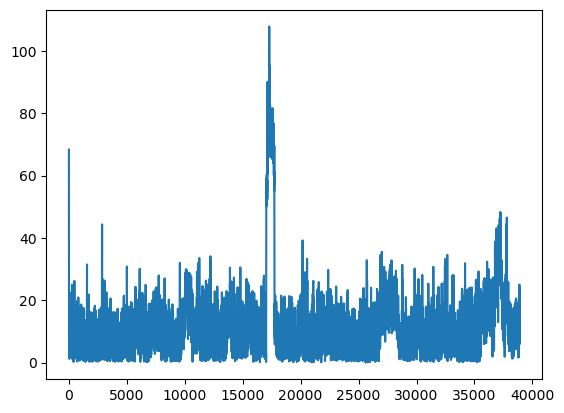

In [28]:
plt.plot(results['spikes_only'].error_cm)
# results['spikes_only'].error_cm

In [24]:
res

{'cell_ids': [309,
  310,
  311,
  312,
  313,
  331,
  335,
  348,
  350,
  352,
  353,
  357,
  359,
  362,
  365,
  367,
  368,
  373,
  375,
  376,
  382,
  383,
  386,
  391,
  395,
  397,
  398,
  399,
  403,
  404,
  405,
  408,
  409,
  411,
  414,
  417,
  418,
  420,
  421,
  422,
  424,
  435,
  439,
  447,
  452,
  453,
  454,
  455,
  456,
  458,
  459,
  473,
  474,
  475,
  476,
  477,
  478,
  480,
  483,
  485,
  487,
  488,
  492,
  495,
  498,
  502,
  503,
  513,
  514,
  516,
  532,
  534,
  535,
  536,
  539,
  540,
  549,
  553,
  556,
  559,
  560,
  563,
  582,
  589,
  590,
  598,
  600,
  601,
  602,
  604,
  605,
  607,
  609,
  613,
  615,
  617,
  620,
  621,
  623,
  626,
  631,
  633,
  635,
  638,
  639,
  644,
  654,
  659,
  662,
  665,
  666,
  668,
  669,
  670,
  671,
  672,
  674,
  682,
  695,
  696,
  699,
  707,
  711,
  716,
  718,
  719,
  733,
  734,
  735,
  737,
  738,
  739,
  747,
  749,
  751,
  752,
  757,
  765,
  766,
  776,
  778,
 

(<Figure size 1200x2600 with 31 Axes>,
 array([[<Axes: title={'center': 'Prev posterior'}>,
         <Axes: title={'center': 'Motion prior (predict)'}>,
         <Axes: title={'center': 'Observation update (weights)'}>],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

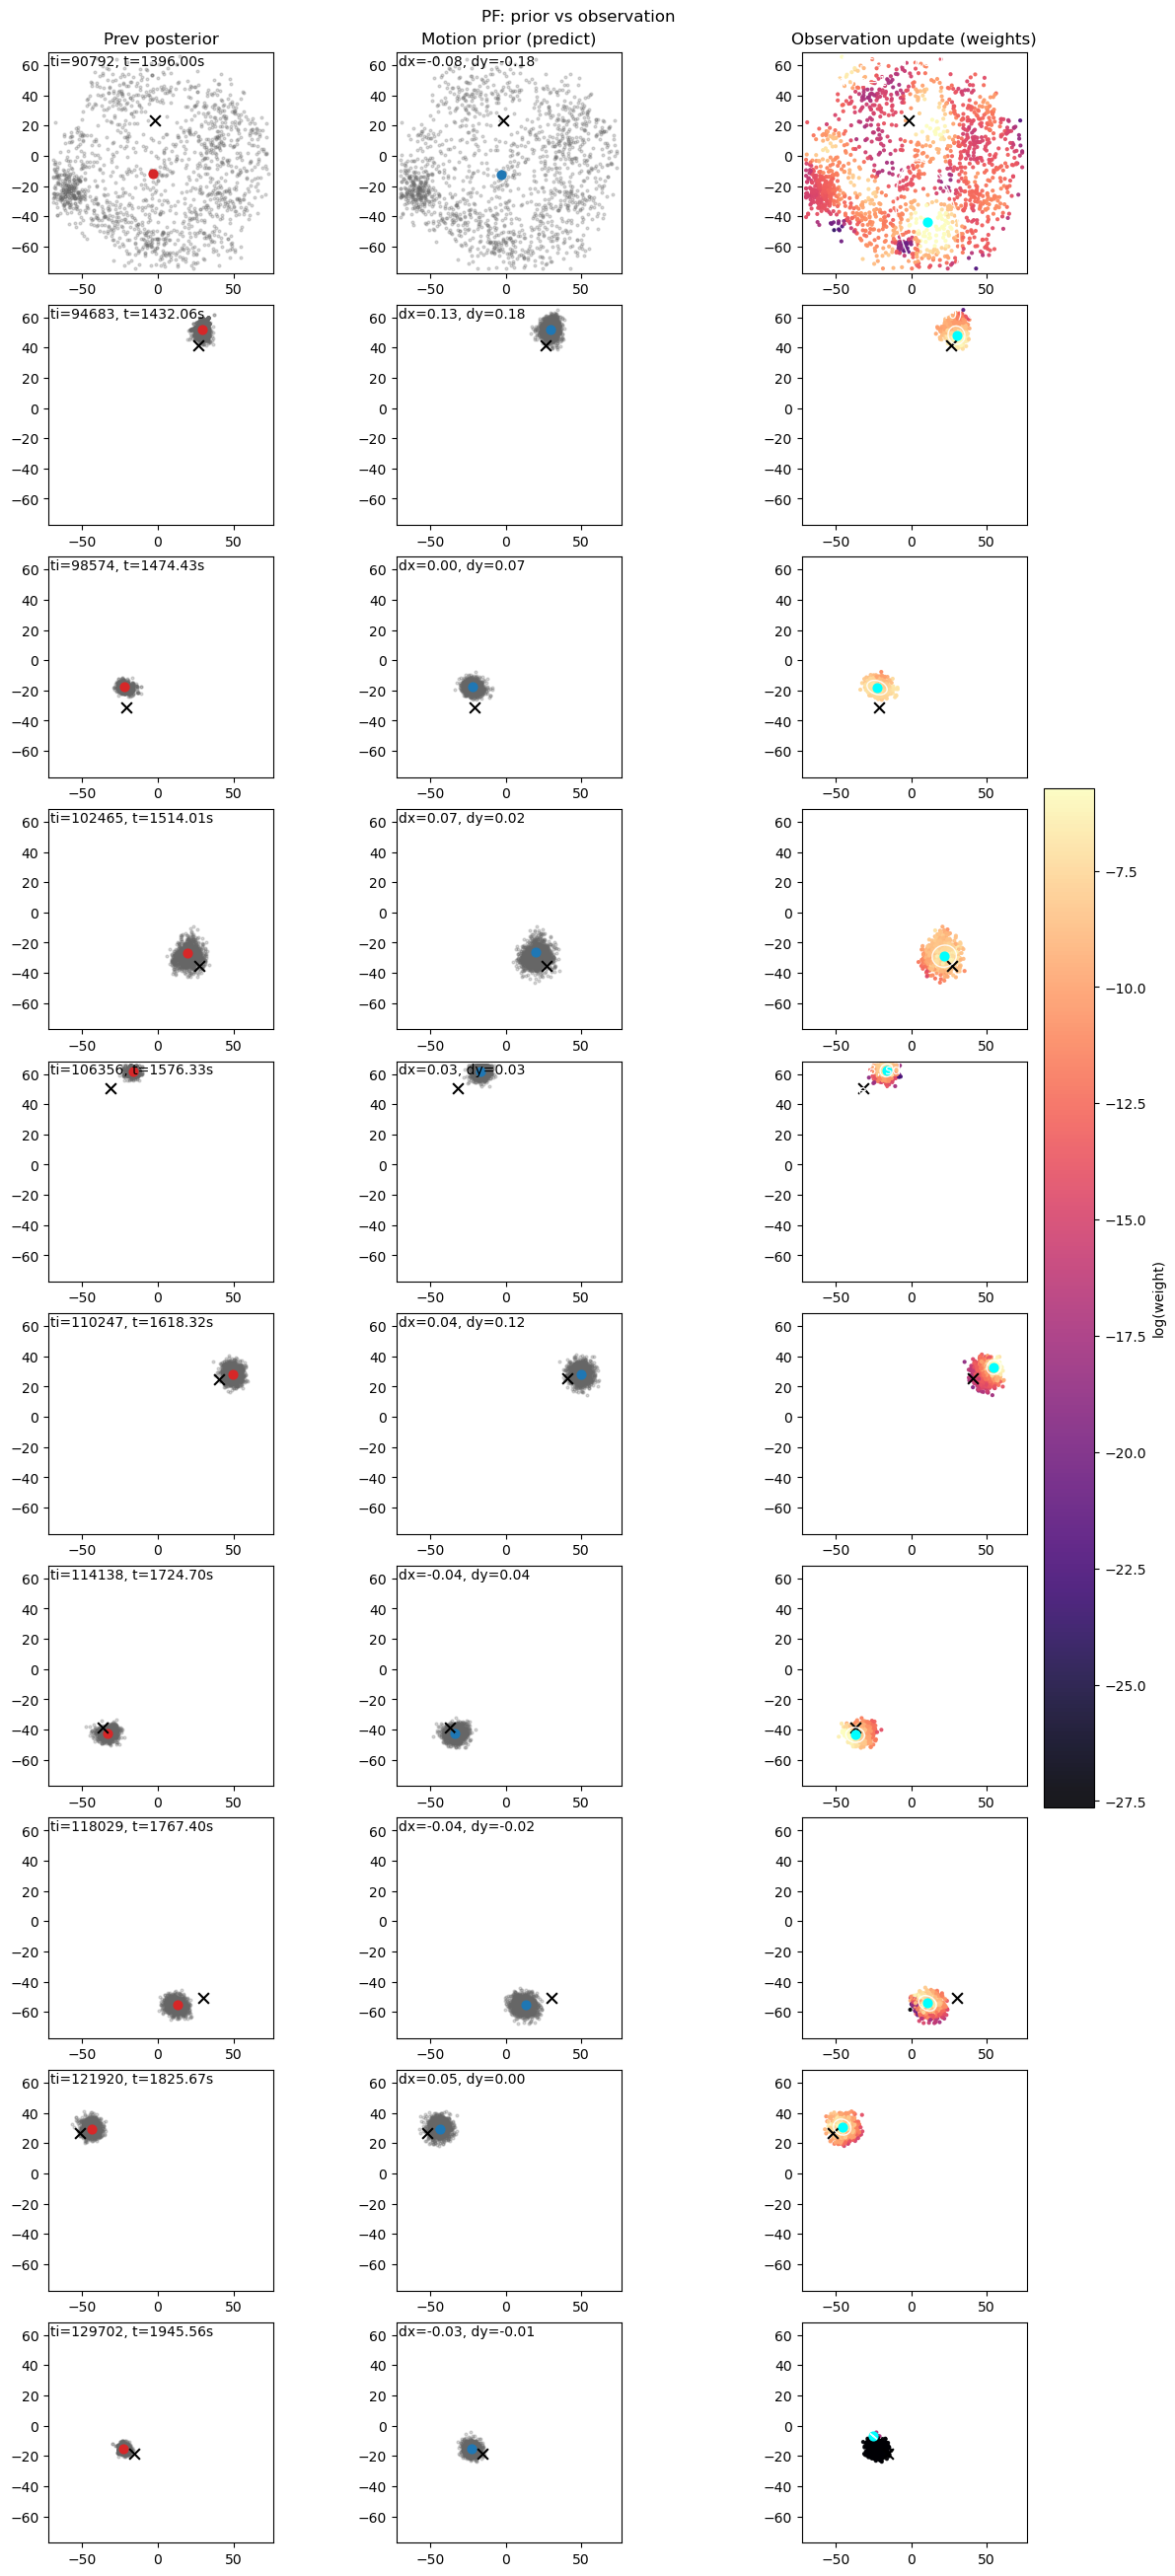

In [29]:
from mec_position_decoder import (
    DecoderConfig, run_decode_comparison,
    pick_nonconsecutive_timepoints,
    decode_particle_filter_with_snapshots,
    plot_particle_filter_snapshots,
)

cfg = DecoderConfig(n_particles=1500, random_seed=0)
res = run_decode_comparison(all_activity, X, Y, T, HD, V, cfg=cfg)

snap_idx = pick_nonconsecutive_timepoints(res["test_idx"], n=10)
dec, snaps = decode_particle_filter_with_snapshots(
    counts=res["counts"],
    x=X, y=Y, t=T, hd=HD, speed=V,
    test_idx=res["test_idx"],
    snapshot_idx=snap_idx,
    rate_maps_hz=res["rate_maps_hz"],
    x_edges=res["x_edges"], y_edges=res["y_edges"],
    occupancy=res["occupancy"],
    cfg=cfg,
    use_motion_prior=True,
)

plot_particle_filter_snapshots(snaps, X, Y, title="PF: prior vs observation")


In [6]:
snap_idx

array([163890, 170913, 177936, 184959, 191982, 199005, 206028, 213051,
       220074, 234120])